In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Dense,          
    LSTM,           
    Conv2D,         
    MaxPooling2D,   
    Flatten,        
    Dropout,        
    BatchNormalization, 
    Input,          
    Bidirectional,  
    GlobalAveragePooling2D  
)
from tensorflow.keras.callbacks import (
    EarlyStopping,    
    ModelCheckpoint, 
    ReduceLROnPlateau 
)

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)


In [2]:
mfcc_data = np.load('../data/processed/mfcc_features.npy')
mel_data  = np.load('../data/processed/mel_features.npy')
labels    = np.load('../data/processed/labels.npy')
with open('../data/processed/emotion_mappings.pkl', 'rb') as f:
    mappings = pickle.load(f)

emotions      = mappings['emotions']
emotion_to_int = mappings['emotion_to_int']
int_to_emotion = mappings['int_to_emotion']

print(f"Features loaded!")
print(f"\nShapes:")
print(f"  MFCC   : {mfcc_data.shape}  ← (samples, time_steps, features)")
print(f"  Mel    : {mel_data.shape} ← (samples, mel_bands, time_frames)")
print(f"  Labels : {labels.shape}")
print(f"\nEmotion mapping: {emotion_to_int}")
print(f"\nLabel distribution:")
for idx, emotion in int_to_emotion.items():
    count = np.sum(labels == idx)
    print(f"  {emotion:<10}: {count}")

Features loaded!

Shapes:
  MFCC   : (14774, 130, 40)  ← (samples, time_steps, features)
  Mel    : (14774, 128, 130) ← (samples, mel_bands, time_frames)
  Labels : (14774,)

Emotion mapping: {'neutral': 0, 'happy': 1, 'sad': 2, 'angry': 3, 'fearful': 4, 'disgust': 5}

Label distribution:
  neutral   : 2199
  happy     : 2515
  sad       : 2515
  angry     : 2515
  fearful   : 2515
  disgust   : 2515


In [3]:
labels_onehot = to_categorical(labels, num_classes=len(emotions))

print(f"Labels shape before one-hot: {labels.shape}")
print(f"Labels shape after one-hot : {labels_onehot.shape}")
print(f"\nExample — label {labels[0]} ({int_to_emotion[labels[0]]}):")
print(f"  Before: {labels[0]}")
print(f"  After : {labels_onehot[0]}")

X_mfcc = mfcc_data
print(f"\nLSTM input shape: {X_mfcc.shape}")
print(f"  N={X_mfcc.shape[0]} samples")
print(f"  {X_mfcc.shape[1]} time steps")
print(f"  {X_mfcc.shape[2]} features per time step")

X_mel = np.expand_dims(mel_data, axis=-1)
print(f"\nCNN input shape: {X_mel.shape}")
print(f"  N={X_mel.shape[0]} samples")
print(f"  {X_mel.shape[1]} mel bands (height)")
print(f"  {X_mel.shape[2]} time frames (width)")
print(f"  {X_mel.shape[3]} channel (grayscale)")


Labels shape before one-hot: (14774,)
Labels shape after one-hot : (14774, 6)

Example — label 3 (angry):
  Before: 3
  After : [0. 0. 0. 1. 0. 0.]

LSTM input shape: (14774, 130, 40)
  N=14774 samples
  130 time steps
  40 features per time step

CNN input shape: (14774, 128, 130, 1)
  N=14774 samples
  128 mel bands (height)
  130 time frames (width)
  1 channel (grayscale)


In [4]:
(X_mfcc_temp, X_mfcc_test,
 X_mel_temp,  X_mel_test,
 y_temp,      y_test) = train_test_split(
    X_mfcc, X_mel, labels_onehot,
    test_size=0.15,
    random_state=42,
    stratify=labels  )

(X_mfcc_train, X_mfcc_val,
 X_mel_train,  X_mel_val,
 y_train,      y_val) = train_test_split(
    X_mfcc_temp, X_mel_temp, y_temp,
    test_size=0.176,
    random_state=42,
    stratify=y_temp.argmax(axis=1)
)

In [5]:
def build_lstm_model(input_shape, num_classes):
    model = Sequential([
         Input(shape=input_shape),
         Bidirectional(LSTM(128, return_sequences=True)),
         Dropout(0.3),
         Bidirectional(LSTM(64, return_sequences=False)),
         Dropout(0.3),
         BatchNormalization(),
         Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    return model

lstm_model = build_lstm_model(
    input_shape=(X_mfcc_train.shape[1], X_mfcc_train.shape[2]),
    num_classes=len(emotions)
)
lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
lstm_model.summary()

2026-03-21 16:29:13.933448: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-21 16:29:13.933645: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-21 16:29:13.933685: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-21 16:29:13.933920: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-21 16:29:13.934363: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional (Bidirection  (None, 130, 256)          173056    
 al)                                                             
                                                                 
 dropout (Dropout)           (None, 130, 256)          0         
                                                                 
 bidirectional_1 (Bidirecti  (None, 128)               164352    
 onal)                                                           
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 batch_normalization (Batch  (None, 128)               512       
 Normalization)                                                  
                                                        

In [6]:
def build_cnn_model(input_shape, num_classes):
    model = Sequential([
        
        Input(shape=input_shape),
        Conv2D(32, kernel_size=(3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(32, kernel_size=(3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2,2)),
        Dropout(0.25),
        Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2,2)),  
        Dropout(0.25),
        Conv2D(128, kernel_size=(3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, kernel_size=(3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2,2)),  # 32×33 → 16×16
        Dropout(0.25),
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    return model
cnn_model = build_cnn_model(
    input_shape=(X_mel_train.shape[1], X_mel_train.shape[2], X_mel_train.shape[3]),
    num_classes=len(emotions)
)

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 130, 32)      320       
                                                                 
 batch_normalization_1 (Bat  (None, 128, 130, 32)      128       
 chNormalization)                                                
                                                                 
 conv2d_1 (Conv2D)           (None, 128, 130, 32)      9248      
                                                                 
 batch_normalization_2 (Bat  (None, 128, 130, 32)      128       
 chNormalization)                                                
                                                                 
 max_pooling2d (MaxPooling2  (None, 64, 65, 32)        0         
 D)                                                              
                                                      

In [7]:
# ============================================================
# CELL 7: SETUP TRAINING CALLBACKS
# ============================================================

# Callbacks are functions that run automatically during training
# They monitor training and take actions to improve results

os.makedirs('../models', exist_ok=True)

def get_callbacks(model_name):
    """
    Creates callbacks for a given model.
    model_name = 'lstm' or 'cnn'
    """
    return [
        
        # EarlyStopping — stops training if model stops improving
        # monitor='val_loss' — watch validation loss
        # patience=10 — wait 10 epochs before stopping
        # restore_best_weights=True — revert to best weights found
        # Why? Prevents wasting time and overfitting
        EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        
        # ModelCheckpoint — saves model when it improves
        # save_best_only=True — only saves when val_accuracy improves
        # This means you always have the best version saved
        ModelCheckpoint(
            filepath=f'../models/{model_name}_best.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        
        # ReduceLROnPlateau — reduces learning rate when stuck
        # monitor='val_loss' — watch validation loss
        # factor=0.5 — multiply learning rate by 0.5
        # patience=5 — wait 5 epochs before reducing
        # min_lr=1e-7 — don't go below this learning rate
        # Why? Small learning rate = smaller steps = fine tuning
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        )
    ]

print("✅ Callbacks ready!")
print("\nCallbacks configured:")
print("  EarlyStopping     — stops if no improvement for 10 epochs")
print("  ModelCheckpoint   — saves best model automatically")
print("  ReduceLROnPlateau — halves learning rate if stuck for 5 epochs")

✅ Callbacks ready!

Callbacks configured:
  EarlyStopping     — stops if no improvement for 10 epochs
  ModelCheckpoint   — saves best model automatically
  ReduceLROnPlateau — halves learning rate if stuck for 5 epochs


In [8]:
# ============================================================
# CELL 8: TRAIN LSTM MODEL
# ============================================================

print("🚀 Training LSTM model...")
print("="*50)

# model.fit() — trains the model
# epochs=50 — maximum training rounds
#   one epoch = model sees ALL training data once
# batch_size=32 — process 32 samples at a time
#   smaller = more updates but slower
#   larger = fewer updates but faster
# validation_data — data model never trains on
#   used to monitor if model is generalizing or memorizing
# callbacks — our monitoring functions from Cell 7
lstm_history = lstm_model.fit(
    X_mfcc_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_mfcc_val, y_val),
    callbacks=get_callbacks('lstm'),
    verbose=1
)

print("\n✅ LSTM training complete!")

# Evaluate on test set
# evaluate() returns loss and accuracy on unseen data
lstm_test_loss, lstm_test_acc = lstm_model.evaluate(
    X_mfcc_test, y_test, verbose=0
)
print(f"\nLSTM Test Accuracy : {lstm_test_acc*100:.2f}%")
print(f"LSTM Test Loss     : {lstm_test_loss:.4f}")

🚀 Training LSTM model...
Epoch 1/50


2026-03-21 16:32:17.305093: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


324/324 [==============================] - ETA: 0s - loss: 1.6204 - accuracy: 0.3504
Epoch 1: val_accuracy improved from -inf to 0.45002, saving model to ../models/lstm_best.keras
324/324 [==============================] - 28s 72ms/step - loss: 1.6204 - accuracy: 0.3504 - val_loss: 1.4746 - val_accuracy: 0.4500 - lr: 0.0010
Epoch 2/50
323/324 [============================>.] - ETA: 0s - loss: 1.1791 - accuracy: 0.5324
Epoch 2: val_accuracy improved from 0.45002 to 0.56671, saving model to ../models/lstm_best.keras
324/324 [==============================] - 22s 67ms/step - loss: 1.1795 - accuracy: 0.5321 - val_loss: 1.0560 - val_accuracy: 0.5667 - lr: 0.0010
Epoch 3/50
324/324 [==============================] - ETA: 0s - loss: 1.1036 - accuracy: 0.5527
Epoch 3: val_accuracy improved from 0.56671 to 0.57802, saving model to ../models/lstm_best.keras
324/324 [==============================] - 1105s 3s/step - loss: 1.1036 - accuracy: 0.5527 - val_loss: 1.0358 - val_accuracy: 0.5780 - lr: 0

In [9]:
# ============================================================
# CELL 9: TRAIN CNN MODEL
# ============================================================

print("🚀 Training CNN model...")
print("="*50)

cnn_history = cnn_model.fit(
    X_mel_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_mel_val, y_val),
    callbacks=get_callbacks('cnn'),
    verbose=1
)

print("\n✅ CNN training complete!")

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(
    X_mel_test, y_test, verbose=0
)
print(f"\nCNN Test Accuracy : {cnn_test_acc*100:.2f}%")
print(f"CNN Test Loss     : {cnn_test_loss:.4f}")

🚀 Training CNN model...
Epoch 1/50
324/324 [==============================] - ETA: 0s - loss: 1.9403 - accuracy: 0.3472
Epoch 1: val_accuracy improved from -inf to 0.27499, saving model to ../models/cnn_best.keras
324/324 [==============================] - 1533s 5s/step - loss: 1.9403 - accuracy: 0.3472 - val_loss: 2.6948 - val_accuracy: 0.2750 - lr: 0.0010
Epoch 2/50
324/324 [==============================] - ETA: 0s - loss: 1.5094 - accuracy: 0.4484
Epoch 2: val_accuracy improved from 0.27499 to 0.33333, saving model to ../models/cnn_best.keras
324/324 [==============================] - 2613s 8s/step - loss: 1.5094 - accuracy: 0.4484 - val_loss: 3.5521 - val_accuracy: 0.3333 - lr: 0.0010
Epoch 3/50
324/324 [==============================] - ETA: 0s - loss: 1.4458 - accuracy: 0.4879
Epoch 3: val_accuracy did not improve from 0.33333
324/324 [==============================] - 2023s 6s/step - loss: 1.4458 - accuracy: 0.4879 - val_loss: 2.6684 - val_accuracy: 0.2705 - lr: 0.0010
Epoch 4/

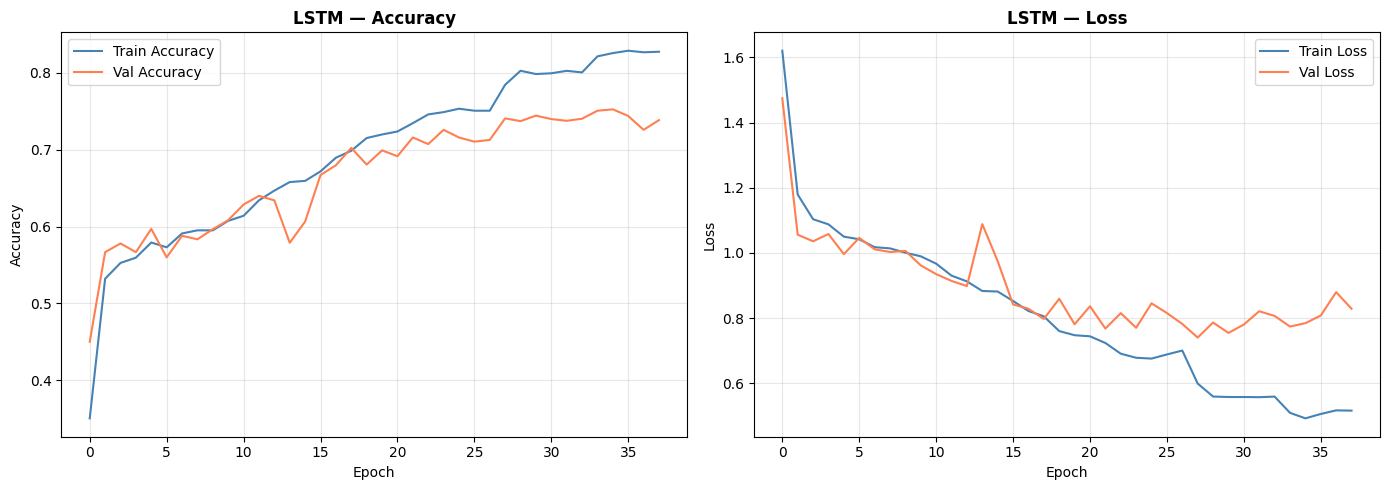

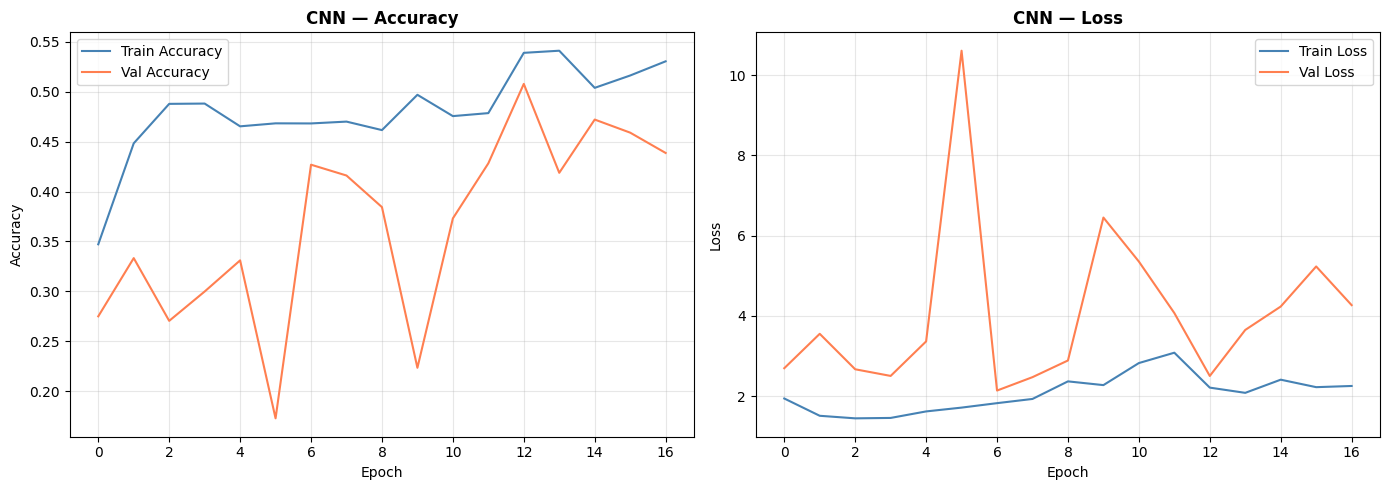

In [10]:
# ============================================================
# CELL 10: VISUALIZE TRAINING HISTORY
# ============================================================

# Training history shows how model improved over epochs
# Helps diagnose overfitting, underfitting, or good fit

def plot_history(history, model_name):
    """
    Plots accuracy and loss curves for training and validation.
    If train accuracy >> val accuracy = overfitting
    If both are low = underfitting
    If both are high and close = good fit
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot Accuracy
    axes[0].plot(history.history['accuracy'],
                 label='Train Accuracy', color='steelblue')
    axes[0].plot(history.history['val_accuracy'],
                 label='Val Accuracy', color='coral')
    axes[0].set_title(f'{model_name} — Accuracy', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot Loss
    axes[1].plot(history.history['loss'],
                 label='Train Loss', color='steelblue')
    axes[1].plot(history.history['val_loss'],
                 label='Val Loss', color='coral')
    axes[1].set_title(f'{model_name} — Loss', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot both models
plot_history(lstm_history, 'LSTM')
plot_history(cnn_history, 'CNN')

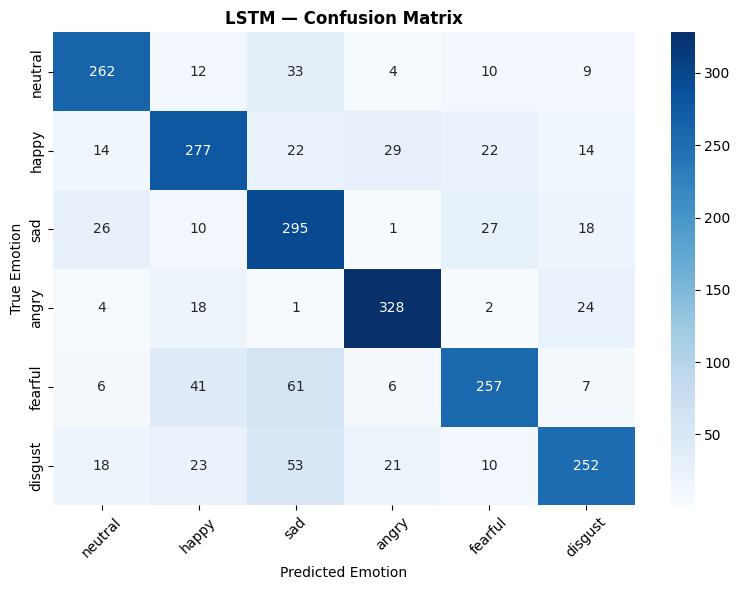


LSTM Classification Report:
              precision    recall  f1-score   support

     neutral       0.79      0.79      0.79       330
       happy       0.73      0.73      0.73       378
         sad       0.63      0.78      0.70       377
       angry       0.84      0.87      0.86       377
     fearful       0.78      0.68      0.73       378
     disgust       0.78      0.67      0.72       377

    accuracy                           0.75      2217
   macro avg       0.76      0.75      0.75      2217
weighted avg       0.76      0.75      0.75      2217



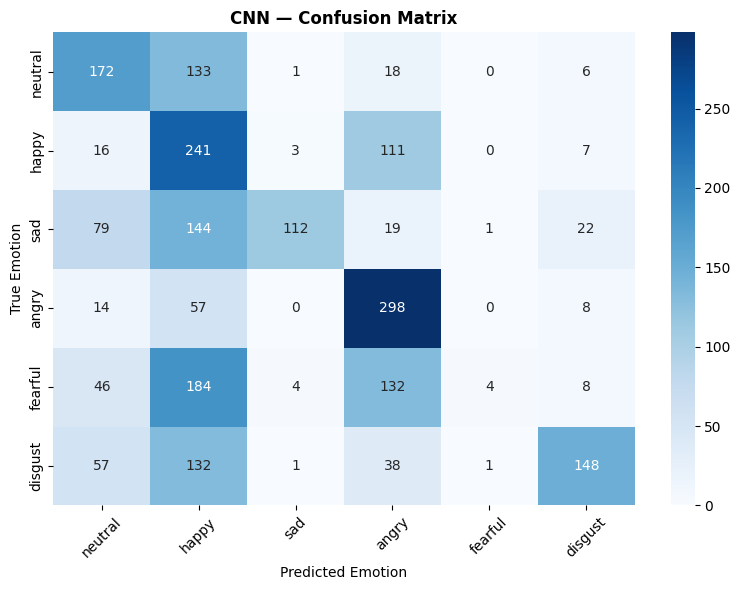


CNN Classification Report:
              precision    recall  f1-score   support

     neutral       0.45      0.52      0.48       330
       happy       0.27      0.64      0.38       378
         sad       0.93      0.30      0.45       377
       angry       0.48      0.79      0.60       377
     fearful       0.67      0.01      0.02       378
     disgust       0.74      0.39      0.51       377

    accuracy                           0.44      2217
   macro avg       0.59      0.44      0.41      2217
weighted avg       0.59      0.44      0.41      2217



In [11]:
# ============================================================
# CELL 11: CONFUSION MATRIX AND CLASSIFICATION REPORT
# ============================================================

# Confusion matrix shows which emotions get confused with each other
# Perfect model = diagonal line only
# Off-diagonal = misclassifications

def evaluate_model(model, X_test, y_test, model_name):
    
    # Get predictions
    # model.predict() returns probability array
    # shape: (N, 6) — probability for each emotion
    y_pred_probs = model.predict(X_test, verbose=0)
    
    # argmax() gets index of highest probability
    # = predicted emotion index
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,          # show numbers in cells
        fmt='d',             # integer format
        cmap='Blues',        # color scheme
        xticklabels=emotions,
        yticklabels=emotions
    )
    plt.title(f'{model_name} — Confusion Matrix', fontweight='bold')
    plt.ylabel('True Emotion')
    plt.xlabel('Predicted Emotion')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Classification report — precision, recall, f1 per emotion
    print(f"\n{model_name} Classification Report:")
    print(classification_report(
        y_true, y_pred,
        target_names=emotions
    ))

evaluate_model(lstm_model, X_mfcc_test, y_test, 'LSTM')
evaluate_model(cnn_model,  X_mel_test,  y_test, 'CNN')

📊 Model Comparison
Model        Test Accuracy    Test Loss
---------------------------------------------
LSTM                75.37%       0.6979
CNN                 43.98%       2.0696


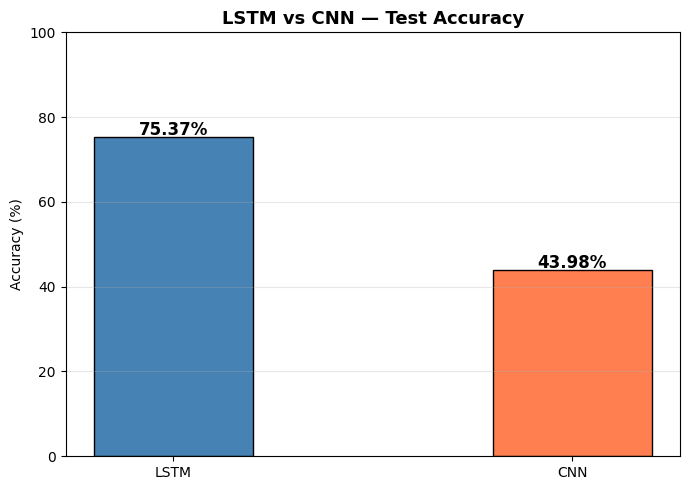


🏆 Winner: LSTM model!


In [12]:
# ============================================================
# CELL 12: COMPARE BOTH MODELS
# ============================================================

print("📊 Model Comparison")
print("="*45)
print(f"{'Model':<10} {'Test Accuracy':>15} {'Test Loss':>12}")
print("-"*45)
print(f"{'LSTM':<10} {lstm_test_acc*100:>14.2f}% {lstm_test_loss:>12.4f}")
print(f"{'CNN':<10} {cnn_test_acc*100:>14.2f}% {cnn_test_loss:>12.4f}")
print("="*45)

# Bar chart comparison
models = ['LSTM', 'CNN']
accuracies = [lstm_test_acc*100, cnn_test_acc*100]
colors = ['steelblue', 'coral']

plt.figure(figsize=(7, 5))
bars = plt.bar(models, accuracies, color=colors, 
               edgecolor='black', width=0.4)

# Add accuracy labels on top of bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{acc:.2f}%',
             ha='center', fontweight='bold', fontsize=12)

plt.title('LSTM vs CNN — Test Accuracy', fontweight='bold', fontsize=13)
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

winner = 'LSTM' if lstm_test_acc > cnn_test_acc else 'CNN'
print(f"\n🏆 Winner: {winner} model!")